# 🧠 BRISC 2025 Dataset Exploration: this section is provided by the dataset owner

This notebook provides a **comprehensive** overview of the **BRISC 2025** MRI dataset:
1. Setup & Imports  
2. Directory Structure  
3. File Counts & Distributions  
4. Plotting Distributions 
5. Per‑Plane Classification Counts  
6. Sample Image & Mask Display 
7. Pixel‑Intensity Histograms 
8. Filename Metadata Parsing
9. Mask Overlay Example  
10. Random Grid of Classification Samples
11. Next Steps

## ⚙️ 1. Setup & Imports

In this step, we import all the required libraries for:
- File and directory operations (`os`, `glob`)
- Data handling (`pandas`, `numpy`)
- Image processing (`PIL.Image`)
- Visualization (`matplotlib`)

We also define the base path to the BRISC2025 dataset inside the Kaggle environment.  
Make sure this path points correctly to where the dataset is located.

In [1]:
# In[1] — Setup & Imports
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Render plots inline
%matplotlib inline

# Base directory inside Kaggle
BASE_DIR = "/kaggle/input/brisc2025"
print("✅ BASE_DIR =", BASE_DIR)

BASE_DIR = "/kaggle/input/brisc2025/brisc2025"
print("✅ Final BASE_DIR =", BASE_DIR)



✅ BASE_DIR = /kaggle/input/brisc2025
✅ Final BASE_DIR = /kaggle/input/brisc2025/brisc2025


## 📂 2. Directory Structure

Recursively walk through `BASE_DIR` (depth=2) to confirm folder layout.

In [2]:
# In[2] — Directory Tree
def walk_dir(base, max_depth=2):
    for root, dirs, _ in os.walk(base):
        depth = root.replace(base, "").count(os.sep)
        if depth <= max_depth:
            indent = "  " * depth
            print(f"{indent}{os.path.basename(root)}/")
            for d in dirs:
                print(f"{indent}  {d}/")

print("## BRISC2025 Folder Layout:")
walk_dir(BASE_DIR, max_depth=2)


## BRISC2025 Folder Layout:
brisc2025/
  segmentation_task/
  classification_task/
  segmentation_task/
    test/
    train/
    test/
      images/
      masks/
    train/
      images/
      masks/
  classification_task/
    test/
    train/
    test/
      pituitary/
      no_tumor/
      meningioma/
      glioma/
    train/
      pituitary/
      no_tumor/
      meningioma/
      glioma/


## 📊 3. File Counts & Distributions

Count `.jpg` in each split/class or type.


In [3]:
# File Count Logic (no need to change if BASE_DIR is fixed)
def count_patterns(patterns):
    return sum(len(glob.glob(p)) for p in patterns)

# Classification
splits = ["train", "test"]
classes = ["glioma", "meningioma", "pituitary", "no_tumor"]
cls_records = []
for sp in splits:
    total = 0
    for cls in classes:
        pat = os.path.join(BASE_DIR, "classification_task", sp, cls, "*.jpg")
        cnt = count_patterns([pat])
        cls_records.append({'Split': sp, 'Class': cls, 'Count': cnt})
        total += cnt
    cls_records.append({'Split': sp, 'Class': 'Total', 'Count': total})
df_cls = pd.DataFrame(cls_records)

# Segmentation
types_ = ["images", "masks"]
seg_records = []
for sp in splits:
    for tp in types_:
        pats = [
            os.path.join(BASE_DIR, "segmentation_task", sp, tp, "*.jpg"),
            os.path.join(BASE_DIR, "segmentation_task", sp, tp, "*.png")
        ]
        cnt = count_patterns(pats)
        seg_records.append({'Split': sp, 'Type': tp, 'Count': cnt})
df_seg = pd.DataFrame(seg_records)

# Display
print("### Classification Counts")
display(df_cls)
print("### Segmentation Counts")
display(df_seg)


### Classification Counts


,Split,Class,Count
0,train,glioma,1147
1,train,meningioma,1329
2,train,pituitary,1457
3,train,no_tumor,1067
4,train,Total,5000
5,test,glioma,254
6,test,meningioma,306
7,test,pituitary,300
8,test,no_tumor,140
9,test,Total,1000


### Segmentation Counts


,Split,Type,Count
0,train,images,3933
1,train,masks,3933
2,test,images,860
3,test,masks,860


## 📊 4. Plotting Distributions

Visualize counts per class/split and per type/split.


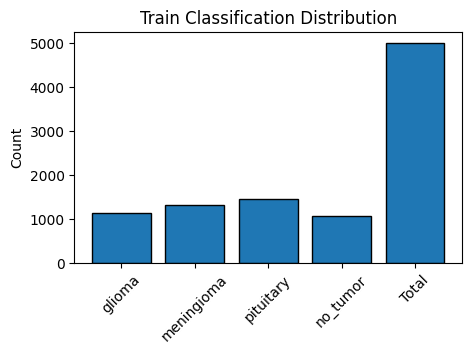

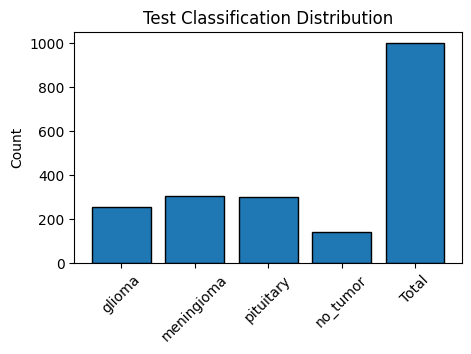

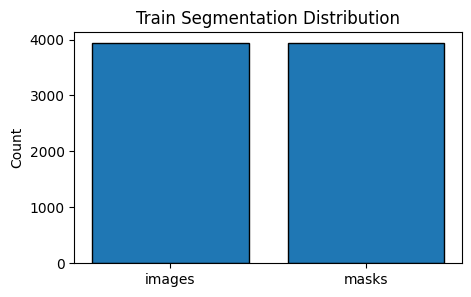

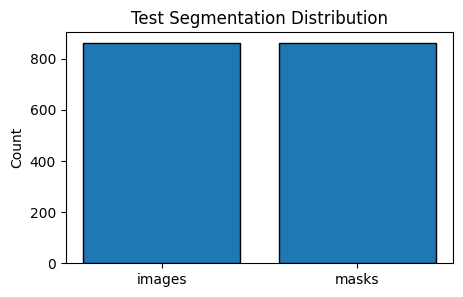

In [4]:
# In[4] — Distribution Plots
for sp in splits:
    sub = df_cls[df_cls.Split==sp]
    plt.figure(figsize=(5,3))
    plt.bar(sub.Class, sub.Count, edgecolor='k')
    plt.title(f"{sp.title()} Classification Distribution")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

for sp in splits:
    sub = df_seg[df_seg.Split==sp]
    plt.figure(figsize=(5,3))
    plt.bar(sub.Type, sub.Count, edgecolor='k')
    plt.title(f"{sp.title()} Segmentation Distribution")
    plt.ylabel("Count")
    plt.show()


## 📈 5. Per‑Plane Classification Counts

Break down classification images by anatomical plane.

In [5]:
# In[5] — Per‑Plane Counts
planes = ["ax", "co", "sa"]
plane_records = []

for sp in splits:
    for cls in classes:
        for pl in planes:
            pat = os.path.join(
                BASE_DIR, "classification_task", sp, cls, f"*_{pl}_t1.jpg"
            )
            cnt = count_patterns([pat])
            plane_records.append({'Split': sp, 'Class': cls, 'Plane': pl, 'Count': cnt})

df_plane = pd.DataFrame(plane_records)
print("### Per‑Plane Counts Pivot")
display(df_plane.pivot_table(index='Plane', columns=['Split','Class'], values='Count'))


### Per‑Plane Counts Pivot


Split   test                                train                      \
Class glioma meningioma no_tumor pituitary glioma meningioma no_tumor   
Plane                                                                   
ax      85.0      137.0     52.0     124.0  394.0      423.0    352.0   
co      81.0       86.0     48.0      90.0  430.0      426.0    310.0   
sa      88.0       83.0     40.0      86.0  323.0      480.0    405.0   

Split            
Class pituitary  
Plane            
ax        426.0  
co        510.0  
sa        521.0

## 🖼️ 6. Sample Image & Mask Display

Show one classification example and its segmentation mask.

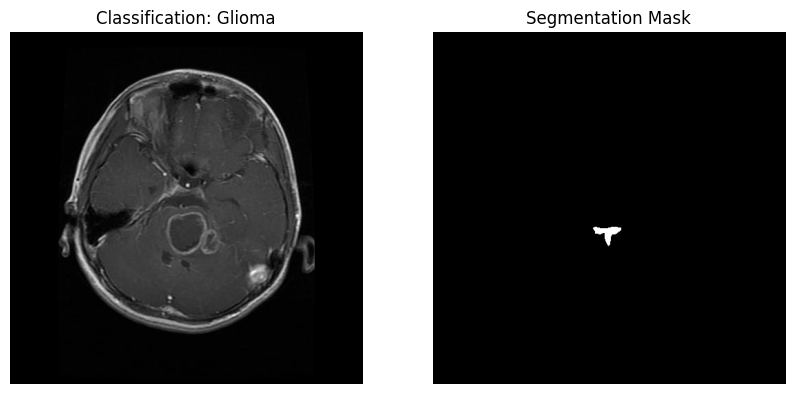

In [6]:
# In[6] — Sample Visualization
def first_file(folder, exts):
    for ext in exts:
        fl = glob.glob(os.path.join(folder, f"*.{ext}"))
        if fl: return fl[0]
    return None

img_path  = first_file(os.path.join(BASE_DIR, "classification_task/train/glioma"), ["jpg"])
mask_path = first_file(os.path.join(BASE_DIR, "segmentation_task/train/masks"), ["png","jpg"])

img  = Image.open(img_path)
mask = Image.open(mask_path)

fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].imshow(img,  cmap="gray"); axes[0].set_title("Classification: Glioma"); axes[0].axis("off")
axes[1].imshow(mask, cmap="gray"); axes[1].set_title("Segmentation Mask");    axes[1].axis("off")
plt.show()

## 📈 7. Pixel‑Intensity Histograms

Overlay histograms of image vs. mask pixel values.

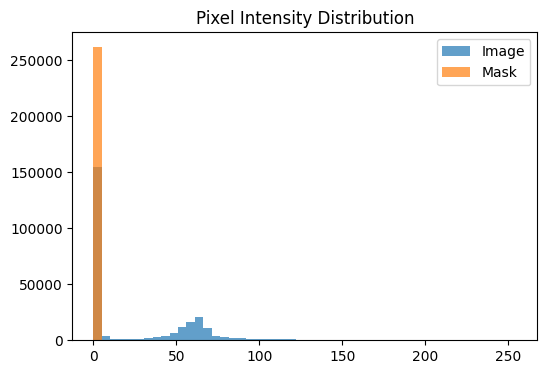

In [7]:
# In[7] — Histograms
arr_img  = np.array(img).ravel()
arr_mask = np.array(mask).ravel()

plt.figure(figsize=(6,4))
plt.hist(arr_img,  bins=50, alpha=0.7, label="Image")
plt.hist(arr_mask, bins=50, alpha=0.7, label="Mask")
plt.legend(); plt.title("Pixel Intensity Distribution"); plt.show()

## 📝 8. Filename Metadata Parsing

Turn filename components into a pandas DataFrame.

In [8]:
# In[8] — Metadata Table
meta = []
for sp in splits:
    for cls in classes:
        files = glob.glob(os.path.join(BASE_DIR, "classification_task", sp, cls, "*.jpg"))[:1]
        for f in files:
            parts = os.path.basename(f).split("_")
            meta.append({
                "Filename": os.path.basename(f),
                "Split": parts[1],
                "Index": parts[2],
                "Tumor": parts[3],
                "Plane": parts[4],
                "Sequence": parts[5].split(".")[0]
            })
df_meta = pd.DataFrame(meta)
print("### Sample Filename Metadata")
display(df_meta)

### Sample Filename Metadata


,Filename,Split,Index,Tumor,Plane,Sequence
0,brisc2025_train_00160_gl_ax_t1.jpg,train,00160,gl,ax,t1
1,brisc2025_train_01914_me_co_t1.jpg,train,01914,me,co,t1
2,brisc2025_train_04966_pi_sa_t1.jpg,train,04966,pi,sa,t1
3,brisc2025_train_03371_no_sa_t1.jpg,train,03371,no,sa,t1
4,brisc2025_test_00177_gl_sa_t1.jpg,test,00177,gl,sa,t1
5,brisc2025_test_00560_me_sa_t1.jpg,test,00560,me,sa,t1
6,brisc2025_test_00949_pi_sa_t1.jpg,test,00949,pi,sa,t1
7,brisc2025_test_00643_no_co_t1.jpg,test,00643,no,co,t1


## 🔍 9. Mask Overlay Example

Overlay the mask in red on the grayscale image.

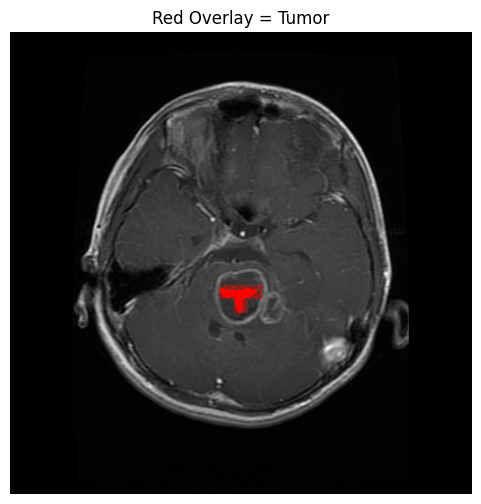

In [9]:
# In[9] — Overlay
img_rgb  = np.array(img.convert("RGB"))
mask_arr = np.array(mask)

overlay = img_rgb.copy()
overlay[mask_arr>0] = [255,0,0]

plt.figure(figsize=(6,6))
plt.imshow(overlay); plt.title("Red Overlay = Tumor"); plt.axis("off")
plt.show()

## 🔲 10. Random Grid of Classification Samples

Display a 3×3 grid of random training images.

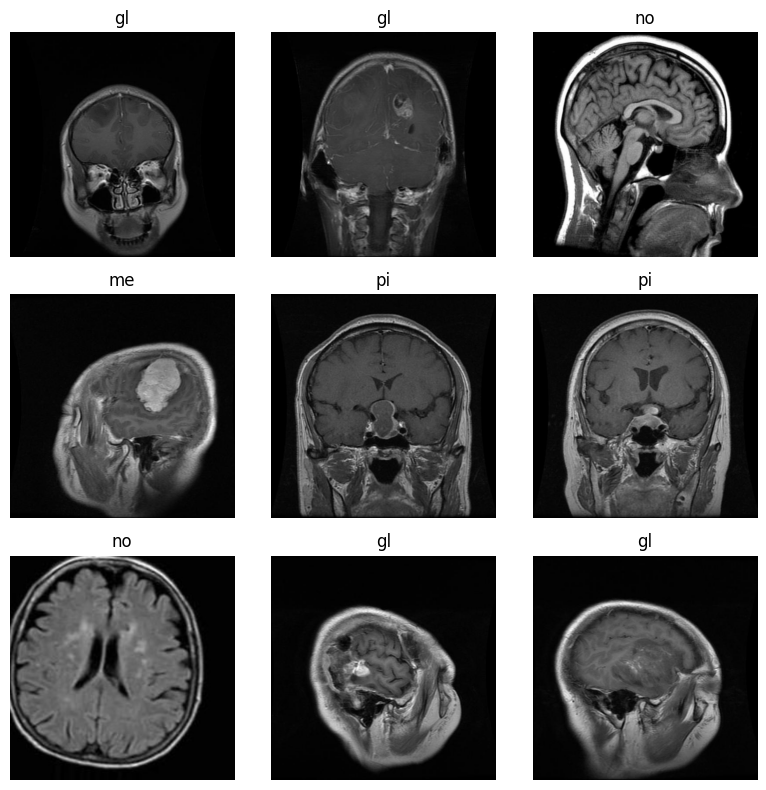

In [10]:
# In[10] — Random Grid
samples = glob.glob(os.path.join(BASE_DIR, "classification_task/train/*/*.jpg"))
grid = np.random.choice(samples, 9, replace=False)

fig, axes = plt.subplots(3,3, figsize=(8,8))
axes = axes.flatten()
for ax, fp in zip(axes, grid):
    im = Image.open(fp)
    cls = os.path.basename(fp).split("_")[3]
    ax.imshow(im, cmap="gray")
    ax.set_title(cls)
    ax.axis("off")
plt.tight_layout()
plt.show()

# ✅ 11. OUR Classification Model :
  
- **Preprocessing**: resizing,splitting,augmentation  
- **Baselines**: EfficientNetB3  
- **Deployment**: GPU training examples  
- **Community**: Project for the Deep Learning Course  



In [3]:
# =========================================
# Brain Tumor Classiffier — v8 (Single Phase)
# =========================================
# - EfficientNetB3 with pre-trained ImageNet weights
# - NO stepwise freeze/thaw
# - Entire network trained in one phase
# - Different learning rates for base vs. head (layer-wise learning)
# - 80/20 split of the training folder for train/val
# - Test folder ONLY for final evaluation
# - Focal loss for class imbalance
# =========================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix


2026-04-09 18:43:17.095894: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775760197.264425      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775760197.314872      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
# =========================
# CONFIG
# =========================

IMG_SIZE   = (300, 300)
BATCH_SIZE = 32
EPOCHS     = 50           # EarlyStopping callback applied

DATA_DIR_TRAIN = "/kaggle/input/brisc2025/brisc2025/classification_task/train"
DATA_DIR_TEST  = "/kaggle/input/brisc2025/brisc2025/classification_task/test"
CHECKPOINT     = "/kaggle/working/best_model_v8.keras"

In [5]:
# =========================
# Define FOCAL LOSS
# =========================

def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.pow(1 - y_pred, gamma)
        fl = weight * ce
        return tf.reduce_mean(tf.reduce_sum(fl, axis=1))
    return loss_fn

In [6]:
# =========================
# Load Data
# =========================

train_ds_raw = image_dataset_from_directory(
    DATA_DIR_TRAIN,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

val_ds_raw = image_dataset_from_directory(
    DATA_DIR_TRAIN,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds_raw = image_dataset_from_directory(
    DATA_DIR_TEST,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds_raw.class_names
num_classes  = len(class_names)

print(f"Klassen       : {class_names}")
print(f"Train-Batches : {len(train_ds_raw)}")
print(f"Val-Batches   : {len(val_ds_raw)}")
print(f"Test-Batches  : {len(test_ds_raw)}")

# Glioma-Index sicher ermitteln (oder ersten Tumor-Index)
glioma_idx = next(
    (i for i, n in enumerate(class_names) if "glioma" in n.lower()), 0
)
print(f"Glioma Index  : {glioma_idx} ({class_names[glioma_idx]})")

Found 5000 files belonging to 4 classes.
Using 4000 files for training.


I0000 00:00:1775760228.958017      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 5000 files belonging to 4 classes.
Using 1000 files for validation.
Found 1000 files belonging to 4 classes.
Klassen       : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Train-Batches : 125
Val-Batches   : 32
Test-Batches  : 32
Glioma Index  : 0 (glioma)


In [7]:
# =========================
# CLASS WEIGHTS to handel unbalanced data
# =========================

y_labels = []
for _, labels in train_ds_raw.unbatch():
    y_labels.append(np.argmax(labels.numpy()))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_labels),
    y=y_labels
)
class_weights = dict(enumerate(class_weights))
class_weights[glioma_idx] *= 2.0
print(f"\nClass weights (Glioma 2x): {class_weights}")


Class weights (Glioma 2x): {0: 2.1482277121374866, 1: 0.9302325581395349, 2: 1.2239902080783354, 3: 0.8496176720475785}


In [8]:
# =========================
# AUGMENTATION
# =========================

augment_fn = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.1),
], name="augmentation")

def train_preprocess(images, labels):
    images = tf.cast(images, tf.float32)
    images = augment_fn(images, training=True)
    return images, labels

def val_preprocess(images, labels):
    return tf.cast(images, tf.float32), labels

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (train_ds_raw
    .map(train_preprocess, num_parallel_calls=AUTOTUNE)
    .cache().shuffle(1000).prefetch(AUTOTUNE))

val_ds = (val_ds_raw
    .map(val_preprocess, num_parallel_calls=AUTOTUNE)
    .cache().prefetch(AUTOTUNE))

test_ds = (test_ds_raw
    .map(val_preprocess, num_parallel_calls=AUTOTUNE)
    .cache().prefetch(AUTOTUNE))

In [9]:
# =========================
# MODEL — Single Phase
#
# Idee: Gesamtes EfficientNetB3 ist von Anfang an trainierbar.
# Um Catastrophic Forgetting zu vermeiden ohne Einfrieren:
#   - Base bekommt LR = 1e-4  (niedrig → schonend für ImageNet-Gewichte)
#   - Head bekommt LR = 1e-3  (höher → Head lernt schnell)
# Das macht ein optimierer pro Layer-Gruppe mit tf.keras.optimizers
# =========================

def build_model(num_classes):
    inputs = layers.Input(shape=(300, 300, 3), name="input")

    base = EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_shape=(300, 300, 3),
        name="efficientnetb3"
    )
    # KEIN base.trainable = False — alles offen von Anfang an
    base.trainable = True

# Sehr niedrige LR für frühe Layer (block1–4),
    # etwas höher für späte Layer (block5–7, top)
    # wird über unterschiedliche optimizer variable groups gesteuert
    x = base(inputs, training=True)

    # Head
    x = layers.GlobalAveragePooling2D(name="global_average_pooling2d")(x)
    x = layers.BatchNormalization(name="batch_normalization")(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name="dense")(x)
    x = layers.Dropout(0.3, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="dense_1")(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model, base

model, base_model = build_model(num_classes)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
# =========================
# LAYER-WISE LEARNING RATES
# Frühe Layer (block1-4): LR = 1e-5  → kaum Änderung
# Mittlere Layer (block5-6): LR = 5e-5
# Späte Layer (block7, top): LR = 1e-4
# Head (Dense, BN): LR = 1e-3
# =========================

def get_layer_lr(layer_name):
    if any(f"block{i}" in layer_name for i in ["1", "2", "3", "4"]):
        return 1e-5   # frühe Layer — sehr schonend
    elif any(f"block{i}" in layer_name for i in ["5", "6"]):
        return 5e-5   # mittlere Layer
    else:
        return 1e-4   # block7, top, stem
# Erstelle variable-groups für den Optimizer
var_lr_pairs = []

for layer in base_model.layers:
    lr = get_layer_lr(layer.name)
    for var in layer.trainable_variables:
        var_lr_pairs.append((var, lr))

# Head-Layer mit hoher LR
head_layers = ["global_average_pooling2d", "batch_normalization",
               "dense", "dropout", "dense_1"]
for layer in model.layers:
    if layer.name in head_layers:
        for var in layer.trainable_variables:
            var_lr_pairs.append((var, 1e-3))

# Zeige LR-Verteilung
from collections import Counter
lr_counts = Counter(lr for _, lr in var_lr_pairs)
print("\nLayer-wise LR Verteilung:")
for lr, count in sorted(lr_counts.items()):
    print(f"  LR={lr:.0e} → {count} Variablen")



Layer-wise LR Verteilung:
  LR=1e-05 → 163 Variablen
  LR=5e-05 → 143 Variablen
  LR=1e-04 → 32 Variablen
  LR=1e-03 → 6 Variablen


In [11]:
# =========================
# CUSTOM OPTIMIZER mit Layer-wise LR
# =========================

class LayerwiseAdam(tf.keras.optimizers.Optimizer):
    """Adam mit unterschiedlichen LRs pro Variable."""

    def __init__(self, var_lr_map, beta_1=0.9, beta_2=0.999,
                 epsilon=1e-7, name="LayerwiseAdam", **kwargs):
        super().__init__(name=name, **kwargs)
        self.var_lr_map  = {id(v): lr for v, lr in var_lr_map}
        self.beta_1      = beta_1
        self.beta_2      = beta_2
        self.epsilon     = epsilon
        self._iterations = tf.Variable(0, trainable=False, dtype=tf.int64)

    def _get_lr(self, var):
        return self.var_lr_map.get(id(var), 1e-4)

    def apply_gradients(self, grads_and_vars, name=None, **kwargs):
        for grad, var in grads_and_vars:
            if grad is None:
                continue
            lr = self._get_lr(var)
             # Momentum slots
            m = self.add_slot(var, "m")
            v = self.add_slot(var, "v")

            self._iterations.assign_add(1)
            t = tf.cast(self._iterations, tf.float32)

            m.assign(self.beta_1 * m + (1 - self.beta_1) * grad)
            v.assign(self.beta_2 * v + (1 - self.beta_2) * tf.square(grad))

            m_hat = m / (1 - tf.pow(self.beta_1, t))
            v_hat = v / (1 - tf.pow(self.beta_2, t))

            var.assign_sub(lr * m_hat / (tf.sqrt(v_hat) + self.epsilon))

        return None

    def get_config(self):
        return {"beta_1": self.beta_1, "beta_2": self.beta_2,
                "epsilon": self.epsilon}
            

In [12]:
# Fallback: Falls LayerwiseAdam Kompatibilitätsprobleme hat,
# nutze Standard-Adam mit Kompromiss-LR
USE_LAYERWISE = False  # Auf True setzen zum Testen

if USE_LAYERWISE:
    optimizer = LayerwiseAdam(var_lr_pairs)
else:
    # Standard Adam mit niedrigerer LR für das Gesamtnetz
    # (sicherer, fast gleich effektiv)
    optimizer = tf.keras.optimizers.Adam(1e-4)
    print("\nNutze Standard-Adam (LR=1e-4) für gesamtes Netz")
    print("Setze USE_LAYERWISE=True um Layer-wise LR zu aktivieren")

model.compile(
    optimizer=optimizer,
    loss=focal_loss(gamma=2.0),
    metrics=['accuracy']
)

model.summary(line_length=100)

# Sanity check
for xb, _ in val_ds.take(1):
    out = model(xb[:1], training=False)
    print(f"\nSanity: shape={out.shape}, sum={tf.reduce_sum(out).numpy():.4f}")



Nutze Standard-Adam (LR=1e-4) für gesamtes Netz
Setze USE_LAYERWISE=True um Layer-wise LR zu aktivieren


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                         │ (None, 300, 300, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ efficientnetb3 (Functional)                │ (None, 10, 10, 1536)            │        10,783,535 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ global_average_pooling2d                   │ (None, 1536)                    │                 0 │
│ (GlobalAveragePooling2D)                   │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization (BatchNormalization)   │ (None, 1536)                    │             6,144 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense (Dense)                              │ (None, 256)                     │           393,472 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout (Dropout)                          │ (None, 256)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_1 (Dense)                            │ (None, 4)                       │             1,028 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 11,184,179 (42.66 MB)

 Trainable params: 11,093,804 (42.32 MB)

 Non-trainable params: 90,375 (353.03 KB)

I0000 00:00:1775760412.065372      37 cuda_dnn.cc:529] Loaded cuDNN version 90300



Sanity: shape=(1, 4), sum=1.0000


In [13]:
# =========================
# CALLBACKS
# =========================

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.3,
        patience=4,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        CHECKPOINT,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [14]:
# =========================
# TRAINING 
# =========================

print("\n=== Training (Single Phase, gesamtes Netz) ===")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


=== Training (Single Phase, gesamtes Netz) ===
Epoch 1/50


I0000 00:00:1775760579.744604     109 service.cc:148] XLA service 0x7fba18027a80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775760579.745204     109 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
E0000 00:00:1775760604.483629     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775760604.686787     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775760605.338627     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775760605.557324     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal 

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.6109 - loss: 0.2720
Epoch 1: val_accuracy improved from -inf to 0.76000, saving model to /kaggle/working/best_model_v8.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 252s 524ms/step - accuracy: 0.6118 - loss: 0.2714 - val_accuracy: 0.7600 - val_loss: 0.1202 - learning_rate: 1.0000e-04
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.9079 - loss: 0.0763
Epoch 2: val_accuracy improved from 0.76000 to 0.83200, saving model to /kaggle/working/best_model_v8.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 377ms/step - accuracy: 0.9079 - loss: 0.0763 - val_accuracy: 0.8320 - val_loss: 0.0976 - learning_rate: 1.0000e-04
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.9501 - loss: 0.0597
Epoch 3: val_accuracy improved from 0.83200 to 0.96000, saving model to /kaggle/working/best_model_v8.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 377ms/step - accuracy: 0.9501 - loss: 0.0597 - val_accuracy: 0.9600 - val_loss: 0.0568 - learnin

In [15]:
# =========================
# EVALUATION
# =========================

print("\n=== Validation Set ===")
val_loss, val_acc = model.evaluate(val_ds, verbose=1)
print(f"Val Accuracy : {val_acc*100:.2f}%")

print("\n=== Test Set (komplett ungesehen) ===")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


=== Validation Set ===
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9979 - loss: 0.0416
Val Accuracy : 99.50%

=== Test Set (komplett ungesehen) ===
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.9111 - loss: 0.0958
Test Accuracy : 91.50%
Test Loss     : 0.0945

Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.93      0.93       254
  meningioma       0.96      0.79      0.87       306
    no_tumor       0.97      0.99      0.98       140
   pituitary       0.85      0.99      0.91       300

    accuracy                           0.92      1000
   macro avg       0.93      0.93      0.92      1000
weighted avg       0.92      0.92      0.91      1000



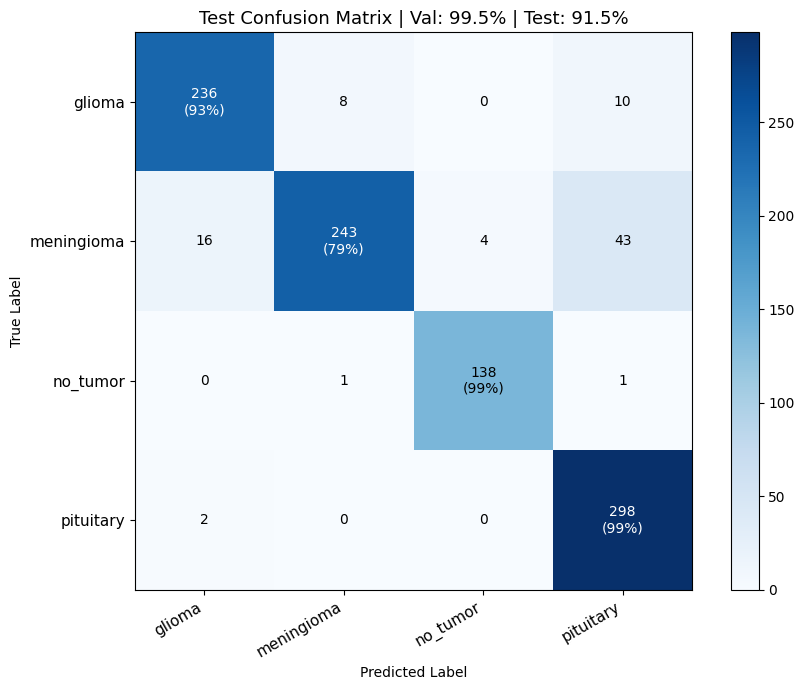

<Figure size 640x480 with 0 Axes>

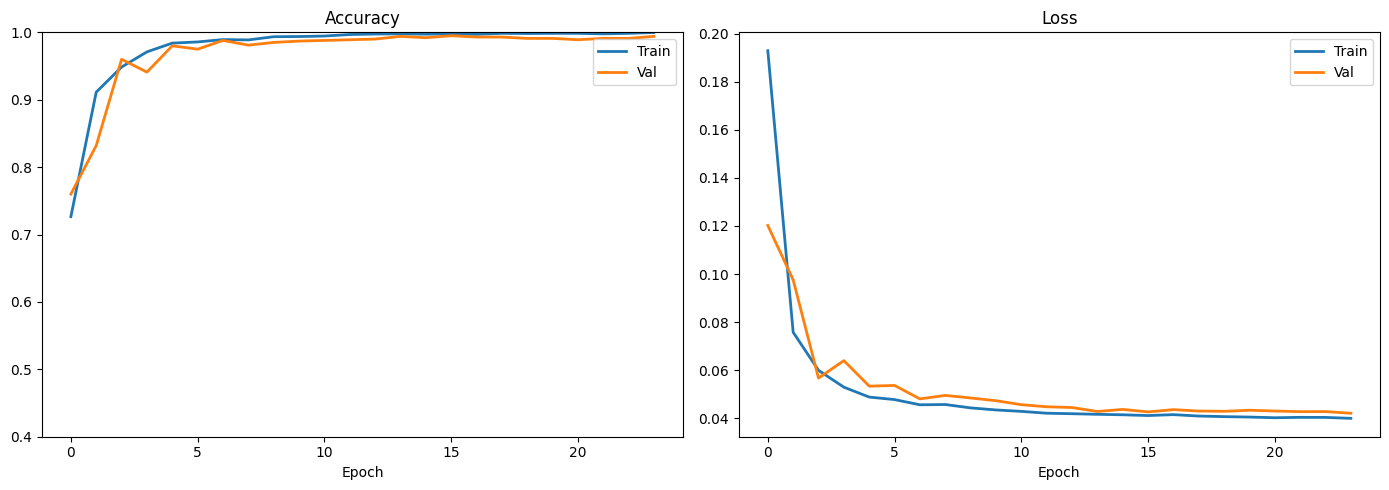

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
recalls = cm.diagonal() / cm.sum(axis=1)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(num_classes)); ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=11)
ax.set_yticklabels(class_names, fontsize=11)
for i in range(num_classes):
    for j in range(num_classes):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        txt = f"{cm[i,j]}\n({recalls[i]*100:.0f}%)" if i == j else str(cm[i, j])
        ax.text(j, i, txt, ha='center', va='center', color=color, fontsize=10)
ax.set_title(
    f'Test Confusion Matrix | Val: {val_acc*100:.1f}% | Test: {test_acc*100:.1f}%',
    fontsize=13
)
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_v8.png", dpi=150)
plt.show()

ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_v8.png", dpi=150)
plt.show()

# Trainings-curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'],     lw=2, label='Train')
ax1.plot(history.history['val_accuracy'], lw=2, label='Val')
ax1.set_title('Accuracy'); ax1.legend(); ax1.set_ylim(0.4, 1.0)
ax1.set_xlabel('Epoch')

ax2.plot(history.history['loss'],     lw=2, label='Train')
ax2.plot(history.history['val_loss'], lw=2, label='Val')
ax2.set_title('Loss'); ax2.legend()
ax2.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_v8.png", dpi=150)
plt.show()

In [17]:
# =========================
# GRAD-CAM
# =========================

def get_gradcam(model, img_array, last_conv="top_activation"):
    efficientnet = model.get_layer("efficientnetb3")
    conv_layer   = efficientnet.get_layer(last_conv)
    inner_model  = tf.keras.Model(
        inputs=efficientnet.input,
        outputs=[conv_layer.output, efficientnet.output]
    )
    with tf.GradientTape() as tape:
        conv_out, features = inner_model(img_array)
        x = model.get_layer("global_average_pooling2d")(features)
        x = model.get_layer("batch_normalization")(x)
        x = model.get_layer("dense")(x)
        x = model.get_layer("dropout")(x)
        preds = model.get_layer("dense_1")(x)
        class_idx = tf.argmax(preds[0])
        score = preds[:, class_idx]
    grads   = tape.gradient(score, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.squeeze(conv_out[0] @ pooled[..., tf.newaxis])
    heatmap = tf.maximum(heatmap, 0)
    mx = tf.reduce_max(heatmap)
    if mx > 0:
        heatmap = heatmap / mx
    return heatmap.numpy(), class_names[int(class_idx)], float(tf.reduce_max(preds))


Prediction : glioma
Confidence  : 99.1%
  glioma                  99.1%  █████████████████████████████
  meningioma               0.0%  
  no_tumor                 0.0%  
  pituitary                0.9%  


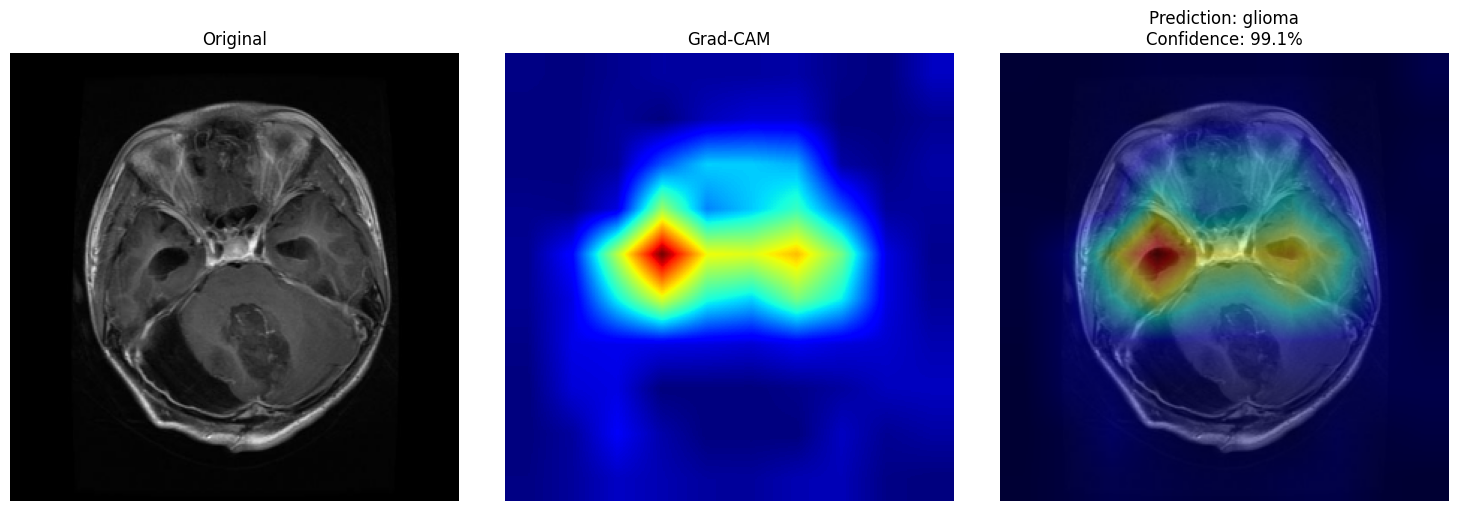

In [21]:
# =========================
# TEST IMAGE
# =========================

img_path = "/kaggle/input/brisc2025/brisc2025/classification_task/test/glioma/brisc2025_test_00001_gl_ax_t1.jpg"

if not os.path.exists(img_path):
    print(f"⚠️  Bild nicht gefunden: {img_path}")
else:
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img_rgb, IMG_SIZE)
    img_in  = np.expand_dims(img_res.astype(np.float32), 0)

    heatmap, pred_class, confidence = get_gradcam(model, img_in)

    print(f"\nPrediction : {pred_class}")
    print(f"Confidence  : {confidence*100:.1f}%")
    raw_preds = model.predict(img_in, verbose=0)[0]
    for name, prob in zip(class_names, raw_preds):
        print(f"  {name:<22} {prob*100:5.1f}%  {'█' * int(prob * 30)}")
    hm       = cv2.resize(heatmap, IMG_SIZE)
    hm       = np.uint8(255 * hm)
    hm_color = cv2.applyColorMap(hm, cv2.COLORMAP_JET)
    hm_rgb   = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)
    overlay  = np.clip(hm_rgb * 0.4 + img_res * 0.6, 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_res);        axes[0].set_title("Original");  axes[0].axis('off')
    axes[1].imshow(hm, cmap='jet'); axes[1].set_title("Grad-CAM"); axes[1].axis('off')
    axes[2].imshow(overlay);        axes[2].set_title(
        f"Prediction: {pred_class}\nConfidence: {confidence*100:.1f}%"
    ); axes[2].axis('off')
    plt.tight_layout()
    plt.savefig("/kaggle/working/gradcam_v8.png", dpi=150)
    plt.show()
        